# MoE Routing & Functional Analysis: Multilingual Models
This notebook analyzes multilingual models to determine whether MoE routing reflects age-linked acoustic specialization (RQ3).


## Routing Analysis Roadmap
This notebook answers two related questions, but keeps them separate:
- **RQ3:** Does age specialization generalize to a multilingual setting?
- **Mechanism:** Does the multilingual model also develop language specialization?

Structure:
- Setup & extraction
- Sanity check: no collapse
- Age specialization within language (NL/DE/EN, bootstrap CIs)
- Language specialization (adult-only control)
- Age vs language competition (overlay + cross-tab)
- EN-only vs multilingual comparison
- Functional analysis (Phase 2)
- Appendix: PL/PAVSig limitations + combined-language sanity check

## Setup & Imports


In [2]:
# ── CELL 1: imports & config ───────────────────────────────────────────────
import os, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2_contingency
import torch.nn.functional as F
import nemo.collections.asr as nemo_asr

MODEL_DIR = "/lp-dev/amelia/inclusive-asr-moe/final_weights"
CACHE_DIR = "routing_outputs_multilingual"
os.makedirs(CACHE_DIR, exist_ok=True)

MODELS = {
    "adult_moe":        f"{MODEL_DIR}/multilingual_adult_moe.nemo",
    "child_moe_lb_on":  f"{MODEL_DIR}/multilingual_child_moe_lb_on.nemo",
    "child_moe_lb_off": f"{MODEL_DIR}/multilingual_child_moe_lb_off.nemo",
}

DENSE_MODELS = {
    "dense_adult": f"{MODEL_DIR}/multilingual_adult_fastconformer.nemo",
    "dense_child": f"{MODEL_DIR}/multilingual_child_fastconformer.nemo",
}

# Each manifest entry: (path, age_group, language, dataset_source)
# PAVSig is included but flagged — clinical corpus, treat results with caution
MANIFESTS = [
    ("/data/cv/nemo/nl/test.json",
     "adult", "nl", "commonvoice"),
    ("/data/cv/nemo/de/test.json",
     "adult", "de", "commonvoice"),
    ("/data/cv/nemo/pl/test.json",
     "adult", "pl", "commonvoice"),
    ("/data/librispeech_nemo/test_clean.json",
     "adult", "en", "librispeech"),
    ("/lp-dev/amelia/data/jasmin/child/test.json",
     "child", "nl", "jasmin"),
    ("/lp-dev/amelia/data/kidstalc/cleaned/val.json",
     "child", "de", "kidstalc"),
    ("/lp-dev/amelia/data/pavsig/training/new_test_manifest.mono.jsonl",
     "child", "pl", "pavsig"),   # clinical corpus — interpret with caution
    ("/lp-dev/amelia/data/myst/test.json",
     "child", "en", "myst"),
]

# Languages that have both adult and child data — valid for age comparison
AGE_COMPARABLE_LANGS = ["nl", "de", "en"]
# PL child = PAVSig (clinical) — include in language analysis, flag in age analysis

N_LAYERS  = 17
N_EXPERTS = 4

LANG_COLORS = {"nl": "#3498DB", "de": "#E74C3C", "pl": "#2ECC71", "en": "#F39C12"}
AGE_COLORS  = {"adult": "#4C72B0", "child": "#DD8452"}
EXPERT_COLORS = {0: "#3498DB", 1: "#E74C3C", 2: "#2ECC71", 3: "#F39C12"}

## Data Collection
Run the multilingual MoE models in eval mode and record router outputs at each of the 17 layers.
Each utterance yields a per-layer expert distribution; later sections aggregate by age and language.

In [3]:
# ── CELL 2: routing extraction (multilingual) ──────────────────────────────
def extract_routing_multilingual(model, manifest_path, age_group,
                                  language, dataset_source,
                                  max_utterances=None, device="cuda"):
    """
    Same hook logic as English notebook.
    Adds language and dataset_source columns to every row.
    """
    model.eval()
    model = model.to(device)

    with open(manifest_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    if max_utterances:
        lines = lines[:max_utterances]

    records          = []
    layer_call_buffer = []

    def router_hook(module, inputs, output):
        logits = output[2]                      # [1, T, 4]
        probs  = torch.softmax(logits.float(), dim=-1)
        probs  = probs.squeeze(0).mean(dim=0)   # [4]
        layer_call_buffer.append(probs.detach().cpu().numpy())

    h = model.encoder.global_router.register_forward_hook(router_hook)

    for line in tqdm(lines, desc=f"{age_group}/{language}/{dataset_source}"):
        data       = json.loads(line)
        audio_path = data.get("audio_filepath")
        if not audio_path or not os.path.exists(audio_path):
            continue
        duration_sec = data.get("duration", data.get("duration_sec"))
        try:
            duration_sec = float(duration_sec)
        except (TypeError, ValueError):
            duration_sec = np.nan

        layer_call_buffer.clear()

        try:
            with torch.no_grad():
                model.transcribe([audio_path], batch_size=1, verbose=False)
        except Exception as e:
            print(f"Failed: {audio_path}: {e}")
            continue

        if len(layer_call_buffer) != N_LAYERS:
            print(f"Warning: {len(layer_call_buffer)}/17 hooks — skipping")
            continue

        for layer_idx, probs in enumerate(layer_call_buffer):
            entropy = float(-np.sum(probs * np.log(probs + 1e-10)))
            row = {
                "utterance_id":   audio_path,
                "age_group":      age_group,
                "language":       language,
                "dataset_source": dataset_source,
                "layer_idx":      layer_idx,
                "router_entropy": entropy,
                "top1_expert":    int(np.argmax(probs)),
                "duration_sec":   duration_sec,
            }
            for e in range(N_EXPERTS):
                row[f"expert_{e}_prob"] = float(probs[e])
            records.append(row)

    h.remove()
    return pd.DataFrame(records)


def load_or_extract_multilingual(model_name, model_path, max_utterances=None):
    cache = f"{CACHE_DIR}/{model_name}_routing.csv"
    if os.path.exists(cache):
        print(f"Loading cached: {cache}")
        return pd.read_csv(cache)

    print(f"\nLoading model: {model_name}")
    model = nemo_asr.models.EncDecCTCModelBPE.restore_from(
        model_path, map_location="cuda"
    )

    dfs = []
    for manifest_path, age_group, language, dataset_source in MANIFESTS:
        if not os.path.exists(manifest_path):
            print(f"  Skipping missing: {manifest_path}")
            continue
        df = extract_routing_multilingual(
            model, manifest_path, age_group, language, dataset_source,
            max_utterances=max_utterances
        )
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df["model"] = model_name
    df.to_csv(cache, index=False)

    del model
    torch.cuda.empty_cache()
    print(f"Saved {len(df)} rows → {cache}")
    return df

In [ ]:
# ── CELL 3: run extraction ─────────────────────────────────────────────────
# Smoke test: 200 utterances per manifest
# Remove max_utterances for full run

EXPERT_COLS = [f"expert_{e}_prob" for e in range(N_EXPERTS)]

all_routing = {}
for model_name, model_path in MODELS.items():
    all_routing[model_name] = load_or_extract_multilingual(
        model_name, model_path#, max_utterances=200
    )

df_main = all_routing["child_moe_lb_off"]

print(f"\nRows: {len(df_main)}")
print(f"Age groups:\n{df_main[df_main['layer_idx']==0]['age_group'].value_counts()}")
print(f"\nLanguages:\n{df_main[df_main['layer_idx']==0]['language'].value_counts()}")
print(f"\nDataset sources:\n{df_main[df_main['layer_idx']==0]['dataset_source'].value_counts()}")


Loading model: adult_moe
[NeMo I 2026-05-20 12:00:51 mixins:184] Tokenizer SentencePieceTokenizer initialized with 16384 tokens


[NeMo W 2026-05-20 12:00:54 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    input_cfg: /lp-dev/amelia/inclusive-asr-moe/data/multilingual/train_cv.yaml
    skip_missing_manifest_entries: true
    num_workers: 8
    shuffle: true
    normalize_text: true
    use_lhotse: true
    force_iterable_dataset: true
    min_duration: 0.5
    max_duration: 40.0
    num_buckets: 10
    use_distributed_sampler: false
    bucket_duration_bins:
    - 1.0
    - 3.0
    - 5.0
    - 7.0
    - 9.0
    - 11.0
    - 13.0
    - 15.0
    - 20.0
    - 25.0
    bucket_batch_size:
    - 576
    - 432
    - 288
    - 216
    - 180
    - 144
    - 126
    - 108
    - 72
    - 54
    use_bucketing: true
    
[NeMo W 2026-05-20 12:00:54 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_valida

[NeMo I 2026-05-20 12:00:55 conformer_moe_encoder:467] Created ConformerMoEEncoder with 17 layers, 8 experts per layer, top-2 routing [global shared router]
[NeMo I 2026-05-20 12:00:59 save_restore_connector:286] Model EncDecCTCModelBPE was successfully restored from /lp-dev/amelia/inclusive-asr-moe/final_weights/multilingual_adult_moe.nemo.


adult/nl/commonvoice:   0%|          | 0/13422 [00:00<?, ?it/s][NeMo W 2026-05-20 12:01:00 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-20 12:01:00 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
adult/nl/commonvoice:   0%|          | 1/13422 [00:00<2:53:39,  1.29it/s][NeMo W 2026-05-20 12:01:00 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-20 12:01:00 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the

## Metrics and Plotting Conventions
We report routing distributions, expert load ($\ell_e^{(g)}$), and JSD divergence per layer.
JSD uses all available data; statistical significance is computed on duration-matched subsamples.
Bootstrap CIs are shown for within-language age JSD (NL/DE/EN).
All figures are saved as PNG and shown inline.

In [ ]:
## Section 1 — Sanity check: no collapse
Participation ratio close to 1 indicates collapse; values near $N_{experts}$ indicate healthy routing.

NameError: name 'all_routing' is not defined

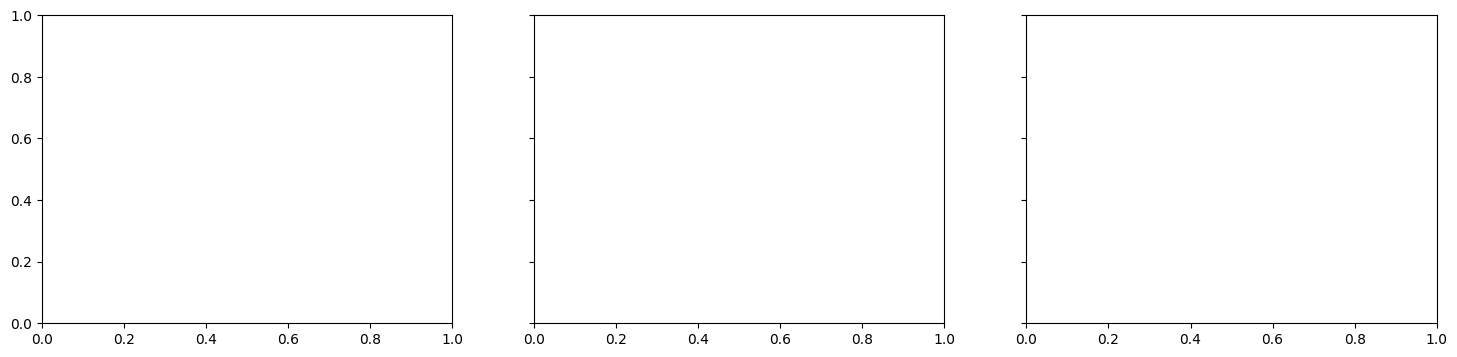

In [ ]:
# ── CELL 4: participation ratio ────────────────────────────────────────────

def participation_ratio(mean_probs):
    return 1.0 / np.sum(mean_probs ** 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (model_name, df) in zip(axes, all_routing.items()):
    for age_group, color in AGE_COLORS.items():
        prs = []
        for layer in range(N_LAYERS):
            df_l   = df[(df["layer_idx"] == layer) &
                        (df["age_group"] == age_group)]
            if df_l.empty:
                prs.append(np.nan)
                continue
            mean_p = df_l[EXPERT_COLS].mean(axis=0).values
            prs.append(participation_ratio(mean_p))
        ax.plot(range(N_LAYERS), prs, marker="o", label=age_group,
                color=color, linewidth=2)

    ax.axhline(N_EXPERTS, color="gray", linestyle="--", alpha=0.5,
               label=f"uniform (PR={N_EXPERTS})")
    ax.axhline(1, color="red", linestyle="--", alpha=0.5, label="collapse")
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel("Layer")
    ax.set_xticks(range(N_LAYERS))
    ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)], fontsize=7)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Participation Ratio")
axes[0].legend(fontsize=8)
plt.suptitle("Participation Ratio — Multilingual Models\n"
             "Gate: values near 1 = collapse, stop analysis for that model",
             fontsize=12)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/participation_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
## Section 2 — Age specialization within language (RQ3)
Within-language adult vs child JSD with bootstrap 95% CIs (NL/DE/EN only).
PL/PAVSig is excluded here and shown only in the appendix.

In [ ]:
# Expert load profiles by language (adult only)
def plot_expert_load_by_language(df, save_path, title):
    languages = sorted(df[df["age_group"] == "adult"]["language"].unique())
    fig, axes = plt.subplots(1, len(languages), figsize=(4.5 * len(languages), 6), sharey=True)
    if len(languages) == 1:
        axes = [axes]
    for ax, lang in zip(axes, languages):
        df_lang = df[(df["language"] == lang) & (df["age_group"] == "adult")]
        load = np.zeros((N_LAYERS, N_EXPERTS))
        for layer in range(N_LAYERS):
            df_l = df_lang[df_lang["layer_idx"] == layer]
            if df_l.empty:
                load[layer] = np.nan
            else:
                probs = df_l[EXPERT_COLS].mean(axis=0).values
                probs = probs / probs.sum() if probs.sum() > 0 else probs
                load[layer] = 2 * probs
        sns.heatmap(
            load, ax=ax, cmap="viridis", vmin=0, vmax=2,
            xticklabels=[f"E{e}" for e in range(N_EXPERTS)],
            yticklabels=range(N_LAYERS),
            cbar=True, cbar_kws={"label": "expert load (avg per frame)"},
        )
        ax.set_title(f"{lang.upper()} adult")
        ax.set_xlabel("Expert")
    axes[0].set_ylabel("Layer")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

df_focus = all_routing["child_moe_lb_off"]
plot_expert_load_by_language(
    df_focus,
    save_path=f"{CACHE_DIR}/expert_load_by_language.png",
    title="Expert load by language (adult only) - child_moe_lb_off",
)

NameError: name 'all_routing' is not defined

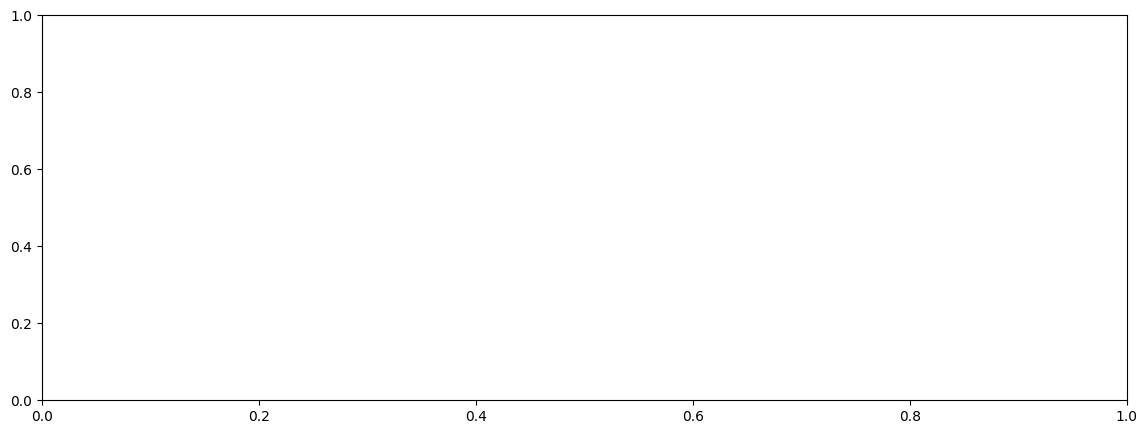

In [ ]:
# ── CELL 5: age JSD helpers (within-language, bootstrap) ──────────────────
BOOTSTRAP_N = 500
BOOTSTRAP_SEED = 42

def _duration_col(df):
    if "duration_sec" in df.columns:
        return df["duration_sec"]
    if "duration" in df.columns:
        return df["duration"]
    return pd.Series([np.nan] * len(df), index=df.index)

def subsample_by_duration(df, target_seconds, seed=42):
    if target_seconds <= 0 or df.empty:
        return df.iloc[0:0]
    df = df.copy()
    df["_duration_sec"] = _duration_col(df)
    df = df[df["_duration_sec"].notna() & (df["_duration_sec"] > 0)]
    if df.empty:
        return df
    df = df.sample(frac=1, random_state=seed)
    cum = df["_duration_sec"].cumsum()
    selected = df[cum <= target_seconds]
    if len(selected) < len(df) and len(selected) > 0:
        selected = pd.concat([selected, df.iloc[[len(selected)]]])
    elif len(selected) == 0:
        selected = df.iloc[[0]]
    return selected.drop(columns=["_duration_sec"])

def _mean_probs(df):
    if df.empty:
        return None
    probs = df[EXPERT_COLS].mean(axis=0).values
    total = probs.sum()
    return probs / total if total > 0 else None

def _jsd_divergence(p, q):
    dist = jensenshannon(p, q, base=2)
    return float(dist * dist)

def bootstrap_jsd_per_layer(df_a, df_b, n_layers=N_LAYERS,
                            n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED):
    means = np.full(n_layers, np.nan)
    ci_low = np.full(n_layers, np.nan)
    ci_high = np.full(n_layers, np.nan)

    for layer in range(n_layers):
        df_a_l = df_a[df_a["layer_idx"] == layer]
        df_b_l = df_b[df_b["layer_idx"] == layer]
        if df_a_l.empty or df_b_l.empty:
            continue

        dur_a = _duration_col(df_a_l).sum()
        dur_b = _duration_col(df_b_l).sum()
        if not np.isfinite(dur_a) or not np.isfinite(dur_b):
            continue
        target = min(float(dur_a), float(dur_b))

        matched_a = subsample_by_duration(df_a_l, target_seconds=target, seed=seed)
        matched_b = subsample_by_duration(df_b_l, target_seconds=target, seed=seed + 1)
        if matched_a.empty or matched_b.empty:
            continue

        boot_vals = []
        for b in range(n_boot):
            sample_a = matched_a.sample(n=len(matched_a), replace=True, random_state=seed + b * 2)
            sample_b = matched_b.sample(n=len(matched_b), replace=True, random_state=seed + b * 2 + 1)
            a = _mean_probs(sample_a)
            b_probs = _mean_probs(sample_b)
            if a is None or b_probs is None:
                continue
            boot_vals.append(_jsd_divergence(a, b_probs))

        if boot_vals:
            vals = np.array(boot_vals)
            means[layer] = float(np.mean(vals))
            ci_low[layer] = float(np.percentile(vals, 2.5))
            ci_high[layer] = float(np.percentile(vals, 97.5))

    return means, ci_low, ci_high

def chi2_significance_duration_matched(df_a, df_b, n_experts, seed=42):
    dur_a = _duration_col(df_a).sum()
    dur_b = _duration_col(df_b).sum()
    if not np.isfinite(dur_a) or not np.isfinite(dur_b):
        return np.nan, False
    target = min(float(dur_a), float(dur_b))
    sub_a = subsample_by_duration(df_a, target_seconds=target, seed=seed)
    sub_b = subsample_by_duration(df_b, target_seconds=target, seed=seed + 1)
    if sub_a.empty or sub_b.empty:
        return np.nan, False
    adult_counts = sub_a["top1_expert"].value_counts()\
        .reindex(range(n_experts), fill_value=0).values
    child_counts = sub_b["top1_expert"].value_counts()\
        .reindex(range(n_experts), fill_value=0).values
    try:
        _, p_val, _, _ = chi2_contingency(np.array([adult_counts, child_counts]))
        return p_val, bool(p_val < 0.05)
    except ValueError:
        return np.nan, False

def compute_jsd_age(df):
    jsd_vals, sig_vals = [], []
    for layer in range(N_LAYERS):
        df_l     = df[df["layer_idx"] == layer]
        df_adult = df_l[df_l["age_group"] == "adult"]
        df_child = df_l[df_l["age_group"] == "child"]
        if df_adult.empty or df_child.empty:
            jsd_vals.append(np.nan); sig_vals.append(False); continue

        p_a = _mean_probs(df_adult)
        p_c = _mean_probs(df_child)
        if p_a is None or p_c is None:
            jsd_vals.append(np.nan); sig_vals.append(False); continue
        jsd = _jsd_divergence(p_a, p_c)

        p_val, sig = chi2_significance_duration_matched(
            df_adult, df_child, n_experts=N_EXPERTS, seed=42
        )

        jsd_vals.append(jsd); sig_vals.append(sig)
    return jsd_vals, sig_vals

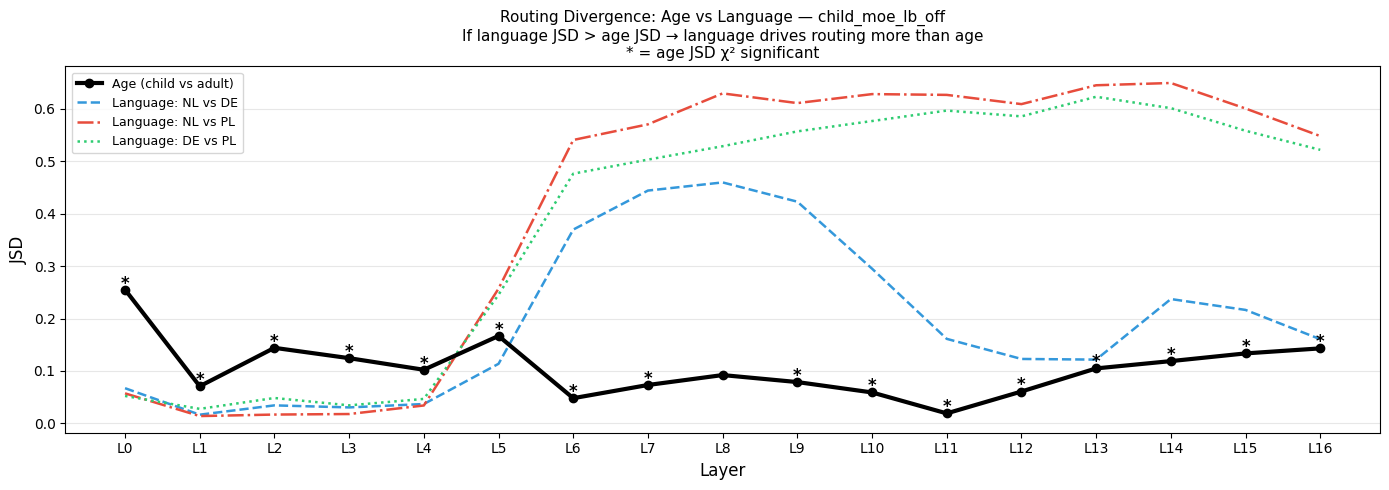

In [ ]:
# ── CELL 6: JSD by language — does routing specialise by language? ─────────
# For each language pair (nl vs de, nl vs pl, de vs pl etc):
# compare routing distributions regardless of age group.
# If JSD(lang_a || lang_b) >> JSD(child || adult) → language drives routing more than age.


def compute_jsd_language_pairs(df):
    """
    For each layer: JSD between each pair of languages (adult utterances only,
    to control for age confound).
    Returns dict {(lang_a, lang_b): [jsd_per_layer]}
    """
    languages = sorted(df["language"].unique())
    pairs     = [(a, b) for i, a in enumerate(languages)
                 for b in languages[i+1:]]
    results   = {}

    for lang_a, lang_b in pairs:
        jsd_vals = []
        for layer in range(N_LAYERS):
            df_l  = df[df["layer_idx"] == layer]
            # Use adult data only to isolate language effect from age effect
            df_la = df_l[(df_l["language"] == lang_a) &
                         (df_l["age_group"] == "adult")]
            df_lb = df_l[(df_l["language"] == lang_b) &
                         (df_l["age_group"] == "adult")]
            if df_la.empty or df_lb.empty:
                jsd_vals.append(np.nan); continue

            p_a = df_la[EXPERT_COLS].mean(axis=0).values.copy(); p_a /= p_a.sum()
            p_b = df_lb[EXPERT_COLS].mean(axis=0).values.copy(); p_b /= p_b.sum()
            jsd_vals.append(float(jensenshannon(p_a, p_b, base=2)))

        results[(lang_a, lang_b)] = jsd_vals

    return results


# Plot: language JSD vs age JSD on same axes for child_moe_lb_off
df_focus = all_routing["child_moe_lb_off"]
lang_jsd  = compute_jsd_language_pairs(df_focus)
age_jsd, age_sig = compute_jsd_age(df_focus)

fig, ax = plt.subplots(figsize=(14, 5))

# Age JSD (thick line)
ax.plot(range(N_LAYERS), age_jsd, marker="o", linewidth=3,
        color="black", label="Age (child vs adult)", zorder=5)

# Mark significant age layers
for i, (v, s) in enumerate(zip(age_jsd, age_sig)):
    if s and not np.isnan(v):
        ax.text(i, v + 0.002, "*", ha="center", fontsize=12,
                fontweight="bold", color="black")

# Language pair JSD (thinner lines)
import itertools
pair_linestyles = itertools.cycle(["--", "-.", ":", "-"] )
pair_colors = sns.color_palette("husl", len(lang_jsd))

for i, ((lang_a, lang_b), vals) in enumerate(lang_jsd.items()):
    ax.plot(range(N_LAYERS), vals,
            linestyle=next(pair_linestyles), color=pair_colors[i], linewidth=1.8,
            label=f"Language: {lang_a.upper()} vs {lang_b.upper()}")

ax.set_xticks(range(N_LAYERS))
ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)])
ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("JSD", fontsize=12)
ax.set_title("Routing Divergence: Age vs Language — child_moe_lb_off\n"
             "If language JSD > age JSD → language drives routing more than age\n"
             "* = age JSD χ² significant",
             fontsize=11)
ax.legend(fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/jsd_age_vs_language.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Pairwise language JSD heatmaps per layer (adult only)
def language_jsd_matrix_by_layer(df):
    languages = sorted(df[df["age_group"] == "adult"]["language"].unique())
    matrices = {}
    for layer in range(N_LAYERS):
        df_l = df[(df["layer_idx"] == layer) & (df["age_group"] == "adult")]
        mat = np.zeros((len(languages), len(languages)))
        for i, la in enumerate(languages):
            for j, lb in enumerate(languages):
                if i == j:
                    mat[i, j] = 0.0
                    continue
                df_a = df_l[df_l["language"] == la]
                df_b = df_l[df_l["language"] == lb]
                if df_a.empty or df_b.empty:
                    mat[i, j] = np.nan
                    continue
                p_a = df_a[EXPERT_COLS].mean(axis=0).values
                p_b = df_b[EXPERT_COLS].mean(axis=0).values
                if p_a.sum() == 0 or p_b.sum() == 0:
                    mat[i, j] = np.nan
                else:
                    p_a = p_a / p_a.sum(); p_b = p_b / p_b.sum()
                    mat[i, j] = float(jensenshannon(p_a, p_b, base=2))
        matrices[layer] = (languages, mat)
    return matrices

layer_mats = language_jsd_matrix_by_layer(df_focus)
LAYERS_TO_PLOT = [0, 8, 16]
for layer in LAYERS_TO_PLOT:
    langs, mat = layer_mats[layer]
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        mat, ax=ax, cmap="YlOrRd", vmin=0, vmax=np.nanmax(mat),
        xticklabels=[l.upper() for l in langs],
        yticklabels=[l.upper() for l in langs],
        annot=True, fmt=".3f",
        cbar_kws={"label": "JSD"},
    )
    ax.set_title(f"Pairwise language JSD (adult) - Layer {layer}")
    plt.tight_layout()
    plt.savefig(f"{CACHE_DIR}/jsd_language_matrix_layer_{layer}.png", dpi=150, bbox_inches="tight")
    plt.show()

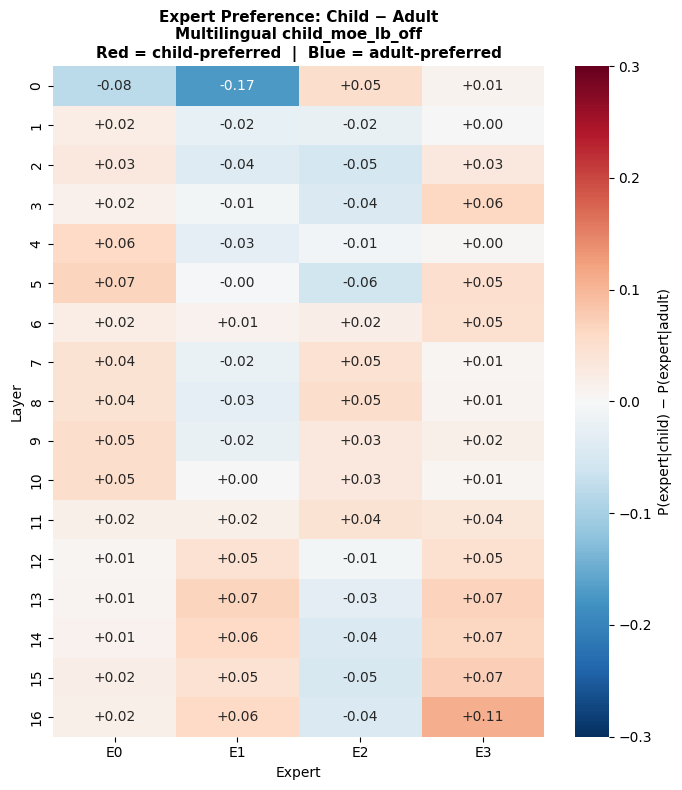

In [ ]:
# ── CELL 7: preference diff heatmap — age (child − adult) ─────────────────
# Same as English Cell 6 but for multilingual model

adult_matrix = np.zeros((N_LAYERS, N_EXPERTS))
child_matrix  = np.zeros((N_LAYERS, N_EXPERTS))

for layer in range(N_LAYERS):
    for age_group, matrix in [("adult", adult_matrix), ("child", child_matrix)]:
        df_l = df_focus[(df_focus["layer_idx"] == layer) &
                        (df_focus["age_group"] == age_group)]
        if not df_l.empty:
            matrix[layer] = df_l[EXPERT_COLS].mean(axis=0).values

diff_age = child_matrix - adult_matrix

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(diff_age, ax=ax, cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3,
            annot=True, fmt="+.2f",
            xticklabels=[f"E{e}" for e in range(N_EXPERTS)],
            yticklabels=range(N_LAYERS),
            cbar_kws={"label": "P(expert|child) − P(expert|adult)"})
ax.set_title("Expert Preference: Child − Adult\n"
             "Multilingual child_moe_lb_off\n"
             "Red = child-preferred  |  Blue = adult-preferred",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Expert"); ax.set_ylabel("Layer")
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/preference_diff_age.png", dpi=150, bbox_inches="tight")
plt.show()

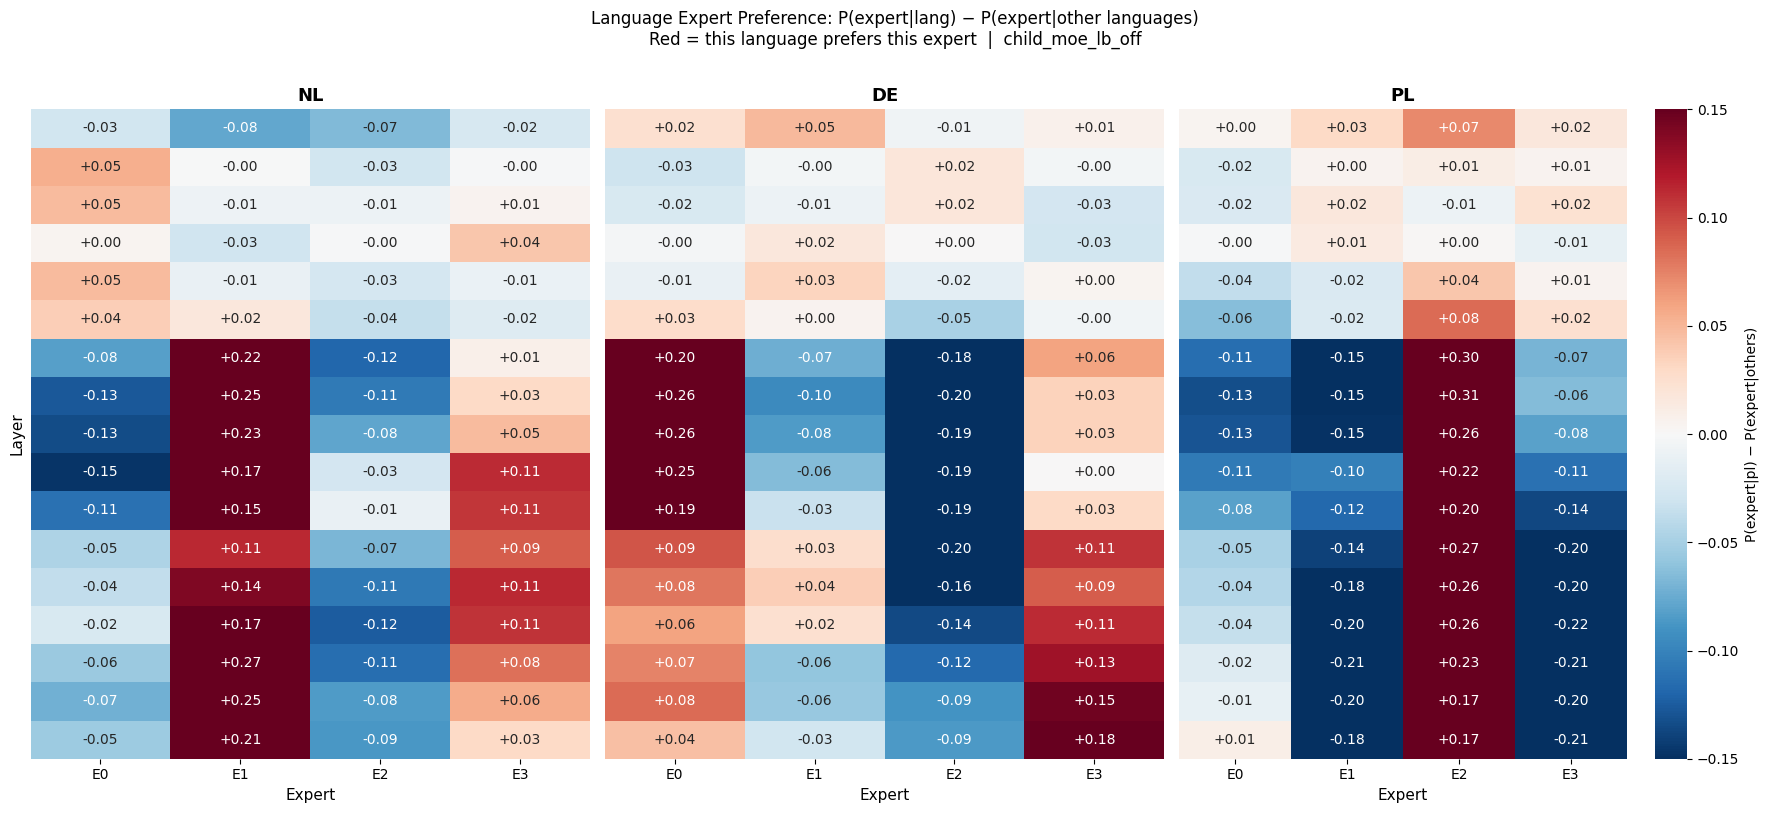

In [ ]:
# ── CELL 8: preference diff heatmaps — per language ───────────────────────
# For each language: P(expert | lang) − P(expert | other_langs_avg)
# Shows whether certain experts are preferentially used for specific languages

languages = ["nl", "de", "pl", "en"]
fig, axes = plt.subplots(1, len(languages),
                          figsize=(4 * len(languages), 8),
                          sharey=True)

for ax, lang in zip(axes, languages):
    lang_matrix  = np.zeros((N_LAYERS, N_EXPERTS))
    other_matrix = np.zeros((N_LAYERS, N_EXPERTS))

    for layer in range(N_LAYERS):
        df_l      = df_focus[df_focus["layer_idx"] == layer]
        df_lang   = df_l[df_l["language"] == lang]
        df_other  = df_l[df_l["language"] != lang]

        if not df_lang.empty:
            lang_matrix[layer]  = df_lang[EXPERT_COLS].mean(axis=0).values
        if not df_other.empty:
            other_matrix[layer] = df_other[EXPERT_COLS].mean(axis=0).values

    diff = lang_matrix - other_matrix

    sns.heatmap(diff, ax=ax, cmap="RdBu_r", center=0, vmin=-0.15, vmax=0.15,
                annot=True, fmt="+.2f",
                xticklabels=[f"E{e}" for e in range(N_EXPERTS)],
                yticklabels=range(N_LAYERS) if lang == languages[0] else [],
                cbar=(lang == languages[-1]),
                cbar_kws={"label": f"P(expert|{lang}) − P(expert|others)"} if lang == languages[-1] else None)

    ax.set_title(f"{lang.upper()}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Expert", fontsize=11)

axes[0].set_ylabel("Layer", fontsize=11)
plt.suptitle("Language Expert Preference: P(expert|lang) − P(expert|other languages)\n"
             "Red = this language prefers this expert  |  child_moe_lb_off",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/preference_diff_language.png", dpi=150, bbox_inches="tight")
plt.show()

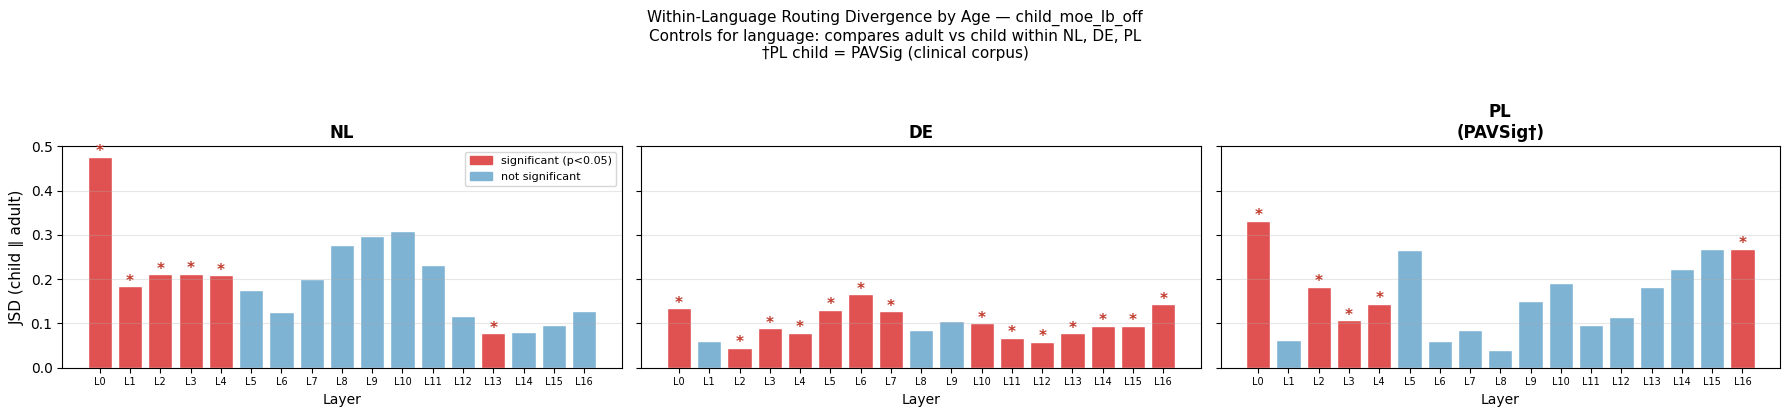

In [ ]:
# ── CELL 9: within-language age comparison ─────────────────────────────────
# The cleanest age analysis: compare adult vs child WITHIN the same language.
# Controls for language confound.
# Valid for NL, DE, and EN.
# PL shown separately with footnote (PAVSig is clinical).

fig, axes = plt.subplots(1, len(languages),
                          figsize=(4 * len(languages), 4),
                          sharey=True)

for ax, lang in zip(axes, languages):
    df_lang   = df_focus[df_focus["language"] == lang]
    jsd_vals  = []
    sig_vals  = []

    for layer in range(N_LAYERS):
        df_l      = df_lang[df_lang["layer_idx"] == layer]
        df_adult  = df_l[(df_l["age_group"] == "adult")]
        df_child  = df_l[(df_l["age_group"] == "child")]

        if df_adult.empty or df_child.empty:
            jsd_vals.append(np.nan); sig_vals.append(False); continue

        p_a = df_adult[EXPERT_COLS].mean(axis=0).values.copy(); p_a /= p_a.sum()
        p_c = df_child[EXPERT_COLS].mean(axis=0).values.copy();  p_c /= p_c.sum()
        jsd = float(jensenshannon(p_a, p_c, base=2))

        p_val, sig = chi2_significance_duration_matched(
            df_adult, df_child, n_experts=N_EXPERTS, seed=42
        )

        jsd_vals.append(jsd); sig_vals.append(sig)

    bar_colors = ["#E05252" if s else "#7FB3D3" for s in sig_vals]
    ax.bar(range(N_LAYERS), jsd_vals, color=bar_colors, edgecolor="white")

    for i, (v, s) in enumerate(zip(jsd_vals, sig_vals)):
        if s and not np.isnan(v):
            ax.text(i, v + 0.001, "*", ha="center", fontsize=11,
                    fontweight="bold", color="#C0392B")

    title = f"{lang.upper()}"
    if lang == "pl":
        title += "\n(PAVSig†)"
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(range(N_LAYERS))
    ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)], fontsize=7)
    ax.set_xlabel("Layer", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
axes[0].set_ylabel("JSD (child ∥ adult)", fontsize=11)
axes[0].legend(handles=[Patch(color="#E05252", label="significant (p<0.05)"),
                          Patch(color="#7FB3D3", label="not significant")],
               fontsize=8)

plt.suptitle("Within-Language Routing Divergence by Age — child_moe_lb_off\n"
             "Controls for language: compares adult vs child within NL, DE, PL, EN\n"
             "†PL child = PAVSig (clinical corpus)",
             fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/jsd_within_language_by_age.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Per-language age JSD per model (NL/DE/EN only)
langs = AGE_COMPARABLE_LANGS
model_names = list(all_routing.keys())
fig, axes = plt.subplots(len(langs), len(model_names),
                          figsize=(5 * len(model_names), 3.5 * len(langs)),
                          sharex=True, sharey=True)
if len(langs) == 1:
    axes = [axes]
for r, lang in enumerate(langs):
    for c, model_name in enumerate(model_names):
        ax = axes[r][c] if len(model_names) > 1 else axes[r]
        df = all_routing[model_name]
        df_lang = df[df["language"] == lang]
        jsd_vals = []
        for layer in range(N_LAYERS):
            df_l = df_lang[df_lang["layer_idx"] == layer]
            df_adult = df_l[df_l["age_group"] == "adult"]
            df_child = df_l[df_l["age_group"] == "child"]
            if df_adult.empty or df_child.empty:
                jsd_vals.append(np.nan)
                continue
            p_a = df_adult[EXPERT_COLS].mean(axis=0).values
            p_c = df_child[EXPERT_COLS].mean(axis=0).values
            p_a = p_a / p_a.sum() if p_a.sum() > 0 else p_a
            p_c = p_c / p_c.sum() if p_c.sum() > 0 else p_c
            jsd_vals.append(float(jensenshannon(p_a, p_c, base=2)))
        ax.plot(range(N_LAYERS), jsd_vals, marker="o", linewidth=1.8)
        ax.set_title(f"{model_name} | {lang.upper()}")
        ax.grid(axis="y", alpha=0.3)
        if r == len(langs) - 1:
            ax.set_xlabel("Layer")
        if c == 0:
            ax.set_ylabel("JSD (child || adult)")
        ax.set_xticks(range(N_LAYERS))
        ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)], fontsize=7)
plt.suptitle("Per-language JSD by model (adult vs child)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/jsd_by_language_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## Domain Control (English-only)
The YODAS vs LibriSpeech vs MyST domain control is computed in the English notebook.
The cell below reloads cached results if present to include the plots here.

In [ ]:
DOMAIN_CACHE = "routing_outputs/domain_control_routing.csv"
if os.path.exists(DOMAIN_CACHE):
    df_domain = pd.read_csv(DOMAIN_CACHE)
    pairs = [("librispeech", "myst"), ("librispeech", "yodas"), ("myst", "yodas")]
    fig, ax = plt.subplots(figsize=(12, 4))
    for a, b in pairs:
        if a not in df_domain["dataset_source"].unique() or b not in df_domain["dataset_source"].unique():
            continue
        jsd_vals = []
        for layer in range(N_LAYERS):
            df_a = df_domain[(df_domain["dataset_source"] == a) & (df_domain["layer_idx"] == layer)]
            df_b = df_domain[(df_domain["dataset_source"] == b) & (df_domain["layer_idx"] == layer)]
            if df_a.empty or df_b.empty:
                jsd_vals.append(np.nan)
                continue
            p_a = df_a[EXPERT_COLS].mean(axis=0).values
            p_b = df_b[EXPERT_COLS].mean(axis=0).values
            p_a = p_a / p_a.sum() if p_a.sum() > 0 else p_a
            p_b = p_b / p_b.sum() if p_b.sum() > 0 else p_b
            jsd_vals.append(float(jensenshannon(p_a, p_b, base=2)))
        ax.plot(range(N_LAYERS), jsd_vals, marker="o", label=f"{a} vs {b}")
    ax.set_xticks(range(N_LAYERS))
    ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)])
    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD")
    ax.set_title("Domain control JSD (English)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{CACHE_DIR}/jsd_domain_control_english.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Domain control cache not found: {DOMAIN_CACHE}")

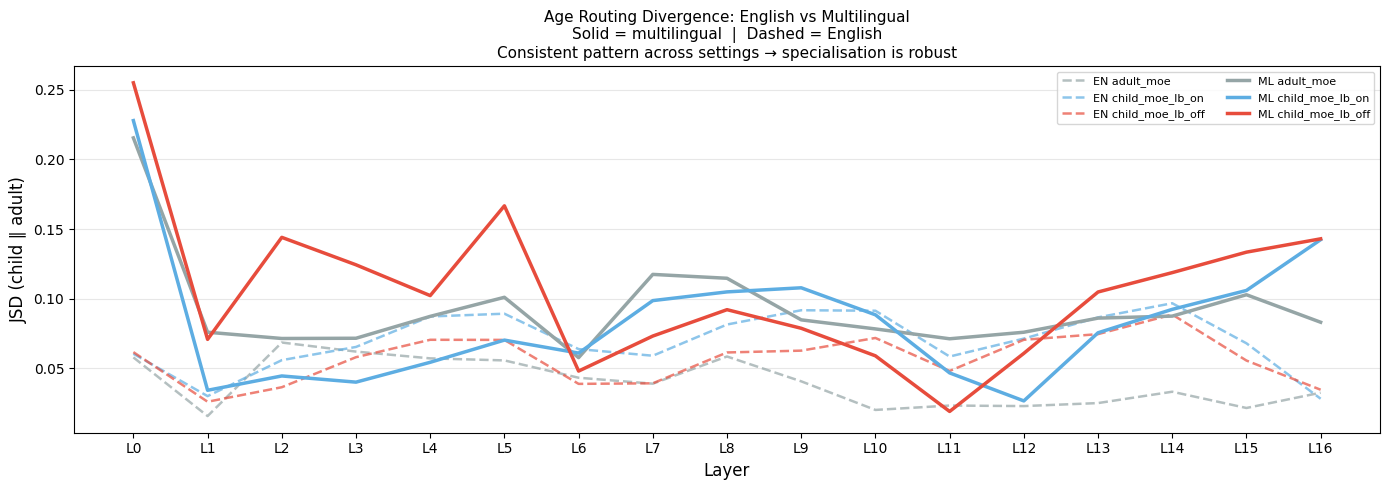

In [29]:
# ── CELL 10: cross-model comparison — EN vs multilingual ──────────────────
# Load English routing results and compare JSD trajectories.
# Tests RQ3: is age specialisation consistent across settings?

EN_CACHE_DIR = "routing_outputs"  # from English notebook

fig, ax = plt.subplots(figsize=(14, 5))

# English models
en_model_styles = {
    "adult_moe":        ("--", "#95A5A6"),
    "child_moe_lb_on":  ("--", "#5DADE2"),
    "child_moe_lb_off": ("--", "#E74C3C"),
}
for model_name, (style, color) in en_model_styles.items():
    cache = f"{EN_CACHE_DIR}/{model_name}_routing.csv"
    if not os.path.exists(cache):
        print(f"Skipping missing EN cache: {cache}")
        continue
    df_en = pd.read_csv(cache)
    jsd_vals, _ = compute_jsd_age(df_en)
    ax.plot(range(N_LAYERS), jsd_vals,
            linestyle=style, color=color, linewidth=1.8, alpha=0.7,
            label=f"EN {model_name}")

# Multilingual models
ml_model_styles = {
    "adult_moe":        ("-", "#95A5A6"),
    "child_moe_lb_on":  ("-", "#5DADE2"),
    "child_moe_lb_off": ("-", "#E74C3C"),
}
for model_name, (style, color) in ml_model_styles.items():
    if model_name not in all_routing:
        continue
    jsd_vals, _ = compute_jsd_age(all_routing[model_name])
    ax.plot(range(N_LAYERS), jsd_vals,
            linestyle=style, color=color, linewidth=2.5,
            label=f"ML {model_name}")

ax.set_xticks(range(N_LAYERS))
ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)])
ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("JSD (child ∥ adult)", fontsize=12)
ax.set_title("Age Routing Divergence: English vs Multilingual\n"
             "Solid = multilingual  |  Dashed = English\n"
             "Consistent pattern across settings → specialisation is robust",
             fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/jsd_en_vs_multilingual.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# ── CELL 11: Phase 2 — output cosine similarity (multilingual) ─────────────
# Same as English Phase 2 but split by language AND age group.
# For each candidate layer × expert:
#   (a) adult vs child cosine similarity (same as English)
#   (b) NL vs DE vs PL cosine similarity (new — language specialisation)

CANDIDATE_LAYERS = [14, 10, 9]   # update from your multilingual JSD results

# Reuse get_expert_outputs_for_utterance from English notebook (same architecture)
# Need to re-define if running this notebook standalone

def collect_reps_by_group(model, manifest_list, layer_idx,
                            max_utterances=200, device="cuda"):
    """
    Collect expert output representations grouped by (age_group, language).
    manifest_list: list of (path, age_group, language, dataset_source)
    Returns dict: {(age_group, language): {expert_id: [n, d_model]}}
    """
    model.eval()
    model = model.to(device)

    ff = model.encoder.layers[layer_idx].feed_forward
    w1 = ff.w1.detach().cpu().float()
    w2 = ff.w2.detach().cpu().float()
    b1 = ff.b1.detach().cpu().float()
    b2 = ff.b2.detach().cpu().float()

    reps = {}   # (age_group, language) -> {e: [vectors]}
    router_buf = {}
    input_buf  = {}

    def ff_hook(module, inputs, output):
        input_buf["x"] = inputs[0].detach().cpu().float().squeeze(0)

    # OmniRouter fires per layer — we only want the call for layer_idx
    call_count = [0]
    def router_hook(module, inputs, output):
        if call_count[0] == layer_idx:
            router_buf["indices"] = output[1].detach().cpu().squeeze(0)
        call_count[0] += 1

    h1 = ff.register_forward_hook(ff_hook)
    h2 = model.encoder.global_router.register_forward_hook(router_hook)

    for manifest_path, age_group, language, dataset_source in manifest_list:
        if not os.path.exists(manifest_path):
            continue
        key = (age_group, language)
        if key not in reps:
            reps[key] = {e: [] for e in range(N_EXPERTS)}

        with open(manifest_path) as f:
            lines = [l.strip() for l in f if l.strip()][:max_utterances]

        for line in tqdm(lines, desc=f"L{layer_idx} | {age_group}/{language}"):
            data       = json.loads(line)
            audio_path = data.get("audio_filepath")
            if not audio_path or not os.path.exists(audio_path):
                continue

            input_buf.clear(); router_buf.clear(); call_count[0] = 0

            try:
                with torch.no_grad():
                    model.transcribe([audio_path], batch_size=1, verbose=False)
            except:
                continue

            if "x" not in input_buf or "indices" not in router_buf:
                continue

            x               = input_buf["x"]
            top1_assignment = router_buf["indices"][:, 0].numpy()

            for e in range(N_EXPERTS):
                mask = top1_assignment == e
                if mask.sum() < 5:
                    continue
                for e2 in range(N_EXPERTS):
                    h_act = x @ w1[e2].T + b1[e2]
                    h_act = F.silu(h_act)
                    out   = h_act @ w2[e2].T + b2[e2]
                    mean_rep = out[mask].mean(dim=0).numpy()
                    reps[key][e2].append(mean_rep)

    h1.remove(); h2.remove()

    # Stack
    for key in reps:
        for e in range(N_EXPERTS):
            v = reps[key][e]
            reps[key][e] = np.stack(v) if v else np.zeros((0, 512))

    return reps


def mean_pairwise_cosine(A, B, n_pairs=300):
    if len(A) == 0 or len(B) == 0:
        return np.nan
    np.random.seed(42)
    idx_a = np.random.choice(len(A), min(len(A), n_pairs), replace=False)
    idx_b = np.random.choice(len(B), min(len(B), n_pairs), replace=False)
    a = F.normalize(torch.tensor(A[idx_a]).float(), dim=1)
    b = F.normalize(torch.tensor(B[idx_b]).float(), dim=1)
    return float((a @ b.T).mean())

In [ ]:
# ── CELL 12: run multilingual Phase 2 ─────────────────────────────────────

REP_CACHE_DIR = f"{CACHE_DIR}/phase2_representations"
os.makedirs(REP_CACHE_DIR, exist_ok=True)

print("Loading child_moe_lb_off for Phase 2...")
model_p2 = nemo_asr.models.EncDecCTCModelBPE.restore_from(
    MODELS["child_moe_lb_off"], map_location="cuda"
)

all_reps_ml = {}

for layer_idx in CANDIDATE_LAYERS:
    cache_path = f"{REP_CACHE_DIR}/layer_{layer_idx}_ml_reps.pkl"

    if os.path.exists(cache_path):
        import pickle
        with open(cache_path, "rb") as f:
            all_reps_ml[layer_idx] = pickle.load(f)
        print(f"Loaded cached: layer {layer_idx}")
        continue

    reps = collect_reps_by_group(
        model_p2, MANIFESTS, layer_idx, max_utterances=200
    )
    all_reps_ml[layer_idx] = reps

    import pickle
    with open(cache_path, "wb") as f:
        pickle.dump(reps, f)
    print(f"Saved layer {layer_idx}")

del model_p2
torch.cuda.empty_cache()

Loading child_moe_lb_off for Phase 2...


[NeMo I 2026-05-19 14:47:47 mixins:184] Tokenizer SentencePieceTokenizer initialized with 16384 tokens


[NeMo W 2026-05-19 14:47:50 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    input_cfg: /lp-dev/amelia/inclusive-asr-moe/data/multilingual/train_child.yaml
    skip_missing_manifest_entries: true
    num_workers: 4
    shuffle: true
    normalize_text: true
    use_lhotse: true
    force_iterable_dataset: true
    min_duration: 1.0
    max_duration: 30.0
    num_buckets: 10
    use_distributed_sampler: false
    bucket_duration_bins:
    - 1.0
    - 3.0
    - 5.0
    - 7.0
    - 9.0
    - 11.0
    - 13.0
    - 15.0
    - 20.0
    - 25.0
    bucket_batch_size:
    - 576
    - 432
    - 288
    - 216
    - 180
    - 144
    - 126
    - 108
    - 72
    - 54
    use_bucketing: true
    
[NeMo W 2026-05-19 14:47:50 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_val

[NeMo I 2026-05-19 14:47:52 conformer_moe_encoder:467] Created ConformerMoEEncoder with 17 layers, 8 experts per layer, top-2 routing [global shared router]
[NeMo I 2026-05-19 14:47:55 save_restore_connector:286] Model EncDecCTCModelBPE was successfully restored from /lp-dev/amelia/inclusive-asr-moe/final_weights/multilingual_child_moe_lb_off.nemo.


L14 | adult/nl:   0%|          | 0/200 [00:00<?, ?it/s][NeMo W 2026-05-19 14:47:55 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-19 14:47:55 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
L14 | adult/nl:   0%|          | 1/200 [00:00<00:27,  7.35it/s][NeMo W 2026-05-19 14:47:55 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-19 14:47:55 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to h

NameError: name 'all_reps_ml' is not defined

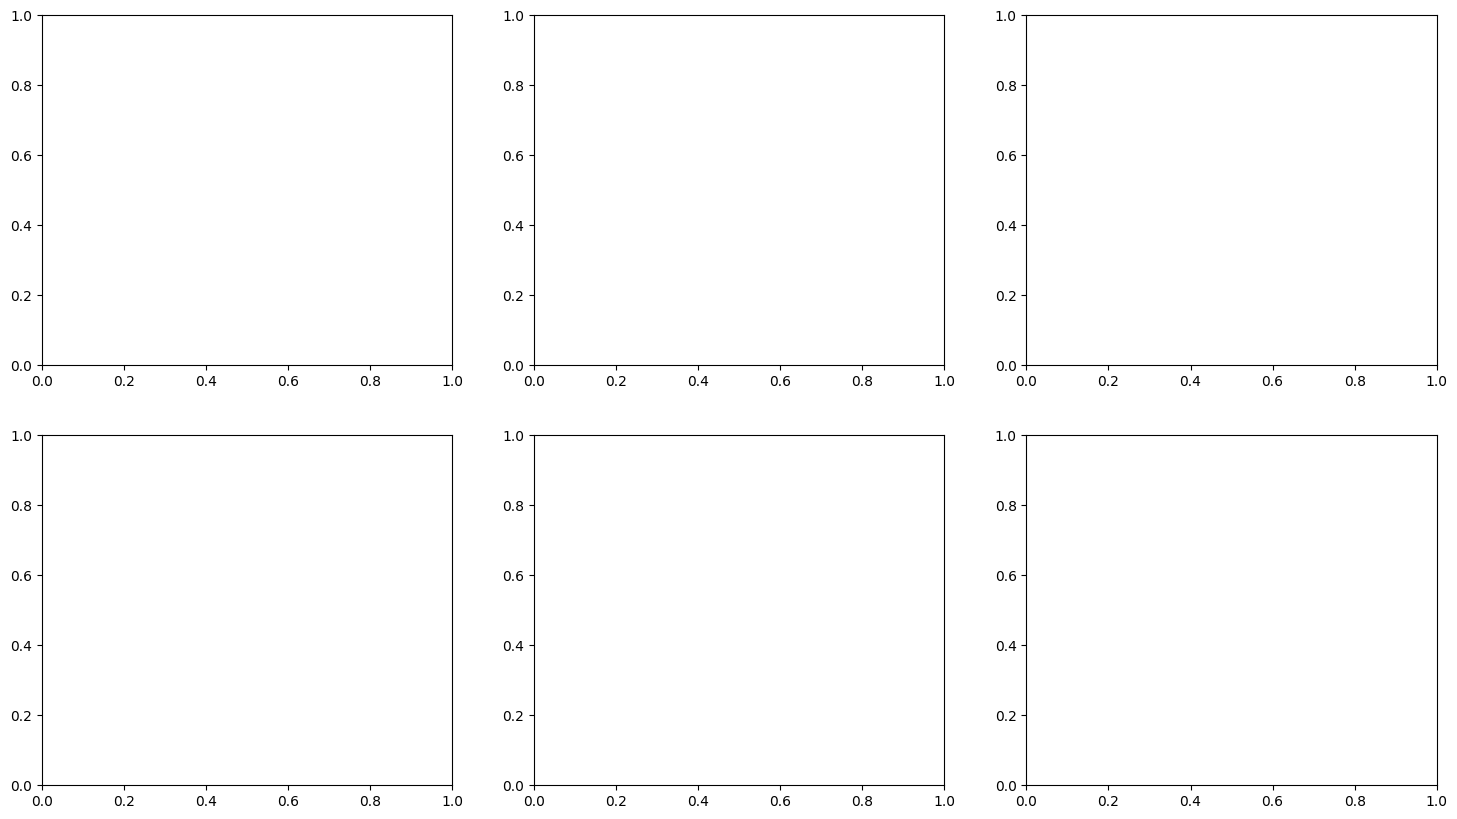

In [7]:
# ── CELL 13: cosine similarity plots ──────────────────────────────────────
# Two plots per candidate layer:
#   (a) adult vs child per expert per language — does specialisation hold within lang?
#   (b) pairs of languages per expert — does routing separate languages?

fig, axes = plt.subplots(2, len(CANDIDATE_LAYERS),
                          figsize=(6 * len(CANDIDATE_LAYERS), 10))

for col, layer_idx in enumerate(CANDIDATE_LAYERS):
    reps = all_reps_ml[layer_idx]

    # ── (a) age similarity within each language ────────────────────────────
    ax = axes[0, col]
    x_pos  = np.arange(N_EXPERTS)
    width  = 0.20
    lang_offsets = {"nl": -1.5*width, "de": -0.5*width, "pl": 0.5*width, "en": 1.5*width}

    for lang, offset in lang_offsets.items():
        sims = []
        for e in range(N_EXPERTS):
            adult_reps = reps.get(("adult", lang), {}).get(e, np.zeros((0,512)))
            child_reps  = reps.get(("child", lang),  {}).get(e, np.zeros((0,512)))
            sims.append(mean_pairwise_cosine(adult_reps, child_reps))

        ax.bar(x_pos + offset, sims, width, label=lang.upper(),
               color=LANG_COLORS[lang], alpha=0.85)

    ax.set_title(f"Layer {layer_idx}\n(a) Age similarity per language",
                 fontsize=10, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"E{e}" for e in range(N_EXPERTS)])
    ax.set_ylabel("Cosine sim (adult vs child)", fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    # ── (b) language similarity within each age group ─────────────────────
    ax = axes[1, col]
    languages = ["nl", "de", "pl", "en"]
    lang_pairs = [(a, b) for i, a in enumerate(languages) for b in languages[i+1:]]
    pair_colors = sns.color_palette("husl", len(lang_pairs))
    age_markers = {"adult": "o", "child": "s"}

    for age_group, marker in age_markers.items():
        for i, (la, lb) in enumerate(lang_pairs):
            sims = []
            for e in range(N_EXPERTS):
                A = reps.get((age_group, la), {}).get(e, np.zeros((0,512)))
                B = reps.get((age_group, lb), {}).get(e, np.zeros((0,512)))
                sims.append(mean_pairwise_cosine(A, B))

            label = f"{la.upper()}-{lb.upper()} ({age_group})"
            ax.plot(range(N_EXPERTS), sims, marker=marker,
                    color=pair_colors[i], linewidth=1.8,
                    linestyle="-" if age_group == "adult" else "--",
                    label=label, alpha=0.85)

    ax.set_title(f"Layer {layer_idx}\n(b) Language similarity per expert",
                 fontsize=10, fontweight="bold")
    ax.set_xticks(range(N_EXPERTS))
    ax.set_xticklabels([f"E{e}" for e in range(N_EXPERTS)])
    ax.set_ylabel("Cosine sim (lang A vs lang B)", fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Phase 2: Expert Output Similarity — Multilingual child_moe_lb_off\n"
             "Top: does each expert harmonise adult+child within same language?\n"
             "Bottom: does routing separate languages?",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/cosine_sim_multilingual.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# ── CELL 14: summary — age vs language specialisation ─────────────────────
# Print a clean table to support thesis interpretation

print("=" * 70)
print("MULTILINGUAL ROUTING ANALYSIS SUMMARY — child_moe_lb_off")
print("=" * 70)

print("\n--- Age JSD by layer (all languages combined) ---")
jsd_age, sig_age = compute_jsd_age(df_focus)
n_sig = sum(sig_age)
max_jsd_layer = int(np.nanargmax(jsd_age))
print(f"  Significant layers: {n_sig}/{N_LAYERS}")
print(f"  Peak JSD: layer {max_jsd_layer} (JSD={jsd_age[max_jsd_layer]:.4f})")

print("\n--- Language JSD (adult utterances only, controls age) ---")
lang_jsd_results = compute_jsd_language_pairs(df_focus)
for (la, lb), vals in lang_jsd_results.items():
    peak = float(np.nanmax(vals))
    peak_layer = int(np.nanargmax(vals))
    print(f"  {la.upper()} vs {lb.upper()}: peak JSD={peak:.4f} at layer {peak_layer}")

print("\n--- Within-language age JSD (NL and DE only) ---")
for lang in ["nl", "de"]:
    df_lang = df_focus[df_focus["language"] == lang]
    jsd_l, sig_l = compute_jsd_age(df_lang)
    n_sig_l = sum(sig_l)
    peak_l  = float(np.nanmax(jsd_l))
    print(f"  {lang.upper()}: {n_sig_l}/{N_LAYERS} significant, "
          f"peak JSD={peak_l:.4f}")

print("\n--- Interpretation ---")
age_peak  = float(np.nanmax(jsd_age))
lang_peak = max(float(np.nanmax(v)) for v in lang_jsd_results.values())
print(f"  Max age JSD:      {age_peak:.4f}")
print(f"  Max language JSD: {lang_peak:.4f}")
if lang_peak > age_peak:
    print("  → Language drives routing MORE than age in this model")
    print("    (language specialisation competes with age specialisation)")
else:
    print("  → Age drives routing MORE than language in this model")
    print("    (age specialisation is primary, robust to multilingual training)")
print()
print("Note: PL child data = PAVSig (clinical corpus). PL age comparisons")
print("may reflect clinical vs naturalistic speech, not age per se.")

MULTILINGUAL ROUTING ANALYSIS SUMMARY — child_moe_lb_off

--- Age JSD by layer (all languages combined) ---


NameError: name 'compute_jsd_age' is not defined